# Modelado MILP de Keccak reducido para minimizar S-boxes activas

**Solver:** CBC  
**Tamaños de palabra:** $z=4$ y $z=8$  
**Experimentos:** una, dos y tres rondas

Este notebook presenta una implementación reproducible para estudiar el número mínimo de S-boxes activas en la capa $\chi$ de Keccak reducido.

$$
\text{intentos}<10 \Longrightarrow R=1,
\qquad
\text{intentos}<20 \Longrightarrow R=2,
\qquad
\text{intentos}<30 \Longrightarrow R=3.
$$


## 1. Alcance

El estado reducido conserva la organización:

$$
A[x,y,k],\qquad x,y\in\{0,\ldots,4\},\qquad k\in\{0,\ldots,z-1\}.
$$

Cada ronda aplica:

$$
\theta \rightarrow \rho \rightarrow \pi \rightarrow \chi \rightarrow \iota.
$$

La capa $\chi$ contiene $5z$ S-boxes por ronda:

- $20$ para $z=4$;
- $40$ para $z=8$.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("No se encontró la raíz del proyecto.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
OUTPUT_DIRECTORY = PROJECT_ROOT / "outputs" / "results"
FIGURE_DIRECTORY = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

print(f"Proyecto : {PROJECT_ROOT}")
print(f"Python   : {sys.executable}")
print(f"Salidas  : {OUTPUT_DIRECTORY}")


Proyecto : D:\Documentos\000. MSC\3er Ciclo\Cripto\PracticaCalificada
Python   : d:\venvs\keccak-milp\Scripts\python.exe
Salidas  : D:\Documentos\000. MSC\3er Ciclo\Cripto\PracticaCalificada\outputs\results


## 2. Reproducción de artefactos

El modo `quick` reconstruye la tabla académica y los archivos de resultados a partir de cotas y testigos previamente certificados. No repite las enumeraciones exhaustivas.


In [2]:
experiment_script = PROJECT_ROOT / "scripts" / "run_active_sbox_experiments.py"

completed = subprocess.run(
    [
        sys.executable,
        str(experiment_script),
        "--mode",
        "quick",
        "--output-dir",
        str(OUTPUT_DIRECTORY),
    ],
    cwd=PROJECT_ROOT,
    check=True,
    capture_output=True,
    text=True,
    encoding="utf-8",
)

print(completed.stdout)


ACTIVE S-BOX EXPERIMENTS
mode        : quick
solver      : CBC
output      : D:\Documentos\000. MSC\3er Ciclo\Cripto\PracticaCalificada\outputs\results

  z   R    status   lower   upper      witness
----------------------------------------------------
  4   1     exact       1       1            1
  4   2     exact       4       4          2+2
  4   3   bounded       5      13        2+2+9
  8   1     exact       1       1            1
  8   2     exact       4       4          2+2
  8   3   bounded       5      14       2+2+10

total time  : 0.000 s

Generated files:
- D:\Documentos\000. MSC\3er Ciclo\Cripto\PracticaCalificada\outputs\results\active_sbox_results.csv
- D:\Documentos\000. MSC\3er Ciclo\Cripto\PracticaCalificada\outputs\results\active_sbox_witnesses.json
- D:\Documentos\000. MSC\3er Ciclo\Cripto\PracticaCalificada\outputs\results\experiment_environment.json
- D:\Documentos\000. MSC\3er Ciclo\Cripto\PracticaCalificada\outputs\results\active_sbox_summary.md



In [3]:
results = pd.read_csv(
    OUTPUT_DIRECTORY / "active_sbox_results.csv",
    encoding="utf-8-sig",
)

witnesses = json.loads(
    (OUTPUT_DIRECTORY / "active_sbox_witnesses.json").read_text(
        encoding="utf-8"
    )
)

environment = json.loads(
    (OUTPUT_DIRECTORY / "experiment_environment.json").read_text(
        encoding="utf-8"
    )
)

assert len(results) == 6
assert environment["solvers"]["cbc_available"] is True

display(results)


,z,rounds,attempts_range,sboxes_per_round,result_status,minimum_exact,lower_bound,upper_bound,witness_activity,search_family,method,evaluated_realizations,elapsed_seconds,solver
0,4,1,<10,20,exact,1.0,1,1,1,global,mathematical lower bound + constructed MILP wi...,NaN,NaN,CBC
1,4,2,<20,20,exact,4.0,4,4,2+2,global,exhaustive differential search + constructed M...,182590.0,NaN,CBC
2,4,3,<30,20,bounded,NaN,5,13,2+2+9,restricted 2+2+c,exhaustive restricted search + constructed MIL...,204800.0,NaN,CBC
3,8,1,<10,40,exact,1.0,1,1,1,global,mathematical lower bound + constructed MILP wi...,NaN,NaN,CBC
4,8,2,<20,40,exact,4.0,4,4,2+2,global,exhaustive differential search + constructed M...,749580.0,NaN,CBC
5,8,3,<30,40,bounded,NaN,5,14,2+2+10,restricted 2+2+c,exhaustive restricted search + constructed MIL...,409600.0,NaN,CBC


## 3. Formulación MILP

Para cada ronda $r$ y posición $(y,k)$ se introduce:

$$
a_{r,y,k}\in\{0,1\}.
$$

La variable es uno cuando la diferencia a la entrada de $\chi$ es no nula:

$$
a_{r,y,k}=\bigvee_{x=0}^{4}\Delta B_r[x,y,k].
$$

La función objetivo es:

$$
\min\sum_{r=0}^{R-1}\sum_{y=0}^{4}\sum_{k=0}^{z-1}a_{r,y,k}.
$$

Además:

$$
\sum_{x,y,k}\Delta A_0[x,y,k]\geq1.
$$


## 4. Matriz de los seis experimentos

- **exact:** la cota inferior y el testigo coinciden;
- **bounded:** existe una cota inferior global y un mejor testigo validado, pero permanece una brecha.


In [4]:
academic_table = results[
    [
        "z",
        "rounds",
        "attempts_range",
        "sboxes_per_round",
        "result_status",
        "minimum_exact",
        "lower_bound",
        "upper_bound",
        "witness_activity",
    ]
].copy()

academic_table = academic_table.rename(
    columns={
        "rounds": "Rondas",
        "attempts_range": "Intentos",
        "sboxes_per_round": "S-boxes por ronda",
        "result_status": "Estado",
        "minimum_exact": "Mínimo exacto",
        "lower_bound": "Cota inferior",
        "upper_bound": "Cota superior",
        "witness_activity": "Testigo",
    }
)

academic_table["Mínimo exacto"] = academic_table["Mínimo exacto"].apply(
    lambda value: "—" if pd.isna(value) else int(value)
)

display(academic_table)


,z,Rondas,Intentos,S-boxes por ronda,Estado,Mínimo exacto,Cota inferior,Cota superior,Testigo
0,4,1,<10,20,exact,1,1,1,1
1,4,2,<20,20,exact,4,4,4,2+2
2,4,3,<30,20,bounded,—,5,13,2+2+9
3,8,1,<10,40,exact,1,1,1,1
4,8,2,<20,40,exact,4,4,4,2+2
5,8,3,<30,40,bounded,—,5,14,2+2+10


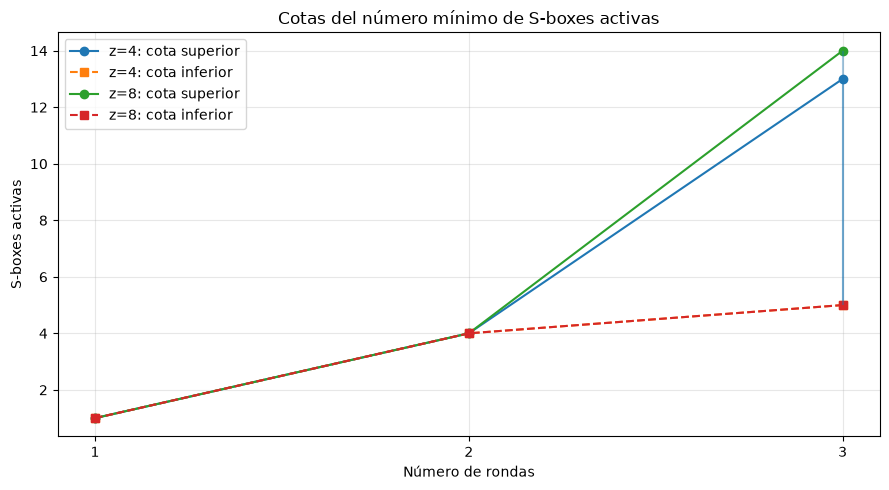

Figura guardada en: D:\Documentos\000. MSC\3er Ciclo\Cripto\PracticaCalificada\outputs\figures\active_sbox_bounds.png


In [5]:
figure, axis = plt.subplots(figsize=(9, 5))

for z, group in results.groupby("z"):
    ordered = group.sort_values("rounds")

    axis.plot(
        ordered["rounds"],
        ordered["upper_bound"],
        marker="o",
        label=f"z={z}: cota superior",
    )

    axis.plot(
        ordered["rounds"],
        ordered["lower_bound"],
        marker="s",
        linestyle="--",
        label=f"z={z}: cota inferior",
    )

    for row in ordered.itertuples():
        axis.vlines(
            row.rounds,
            row.lower_bound,
            row.upper_bound,
            alpha=0.4,
        )

axis.set_title("Cotas del número mínimo de S-boxes activas")
axis.set_xlabel("Número de rondas")
axis.set_ylabel("S-boxes activas")
axis.set_xticks([1, 2, 3])
axis.grid(alpha=0.3)
axis.legend()

figure.tight_layout()

figure_path = FIGURE_DIRECTORY / "active_sbox_bounds.png"
figure.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Figura guardada en: {figure_path}")


## 5. Testigos de tres rondas

Para tres rondas se realizó una búsqueda exhaustiva restringida a:

$$
2+2+c.
$$


In [6]:
for experiment_key in ("z4_rounds3", "z8_rounds3"):
    witness = witnesses["experiments"][experiment_key]

    print("=" * 68)
    print(experiment_key)
    print("=" * 68)
    print("Trayectorias 2+2        :", witness["trail_count"])
    print("Realizaciones evaluadas :", witness["evaluated_realizations"])
    print("Soporte ronda 0         :", witness["support_round_0"])
    print("Soporte ronda 1         :", witness["support_round_1"])
    print("Soporte ronda 2         :", witness["support_round_2"])
    print("Actividad total         :", witness["minimum_total_activity"])
    print()


z4_rounds3
Trayectorias 2+2        : 200
Realizaciones evaluadas : 204800
Soporte ronda 0         : [[2, 0], [4, 0]]
Soporte ronda 1         : [[1, 3], [2, 2]]
Soporte ronda 2         : [[0, 0], [0, 2], [1, 1], [2, 0], [2, 1], [3, 2], [4, 1], [4, 2], [4, 3]]
Actividad total         : 13

z8_rounds3
Trayectorias 2+2        : 400
Realizaciones evaluadas : 409600
Soporte ronda 0         : [[2, 0], [4, 0]]
Soporte ronda 1         : [[3, 2], [4, 2]]
Soporte ronda 2         : [[0, 0], [0, 2], [1, 5], [1, 7], [2, 4], [3, 1], [3, 3], [3, 6], [4, 2], [4, 3]]
Actividad total         : 14



## 6. Demostración práctica

Los siguientes tests reconstruyen estados concretos, ejecutan las rondas de Keccak y comprueban que CBC reproduce la actividad esperada.

La suite global se ejecuta desde PowerShell con:

```powershell
pytest -q
```

En el punto estable de este notebook se aprobaron **245 pruebas**.


In [7]:
targeted_tests = [
    "tests/test_active_sboxes.py::test_constructed_single_active_sbox_witness_z4",
    "tests/test_active_sboxes.py::test_two_round_constructed_witness_has_two_plus_two_active_sboxes",
    "tests/test_active_sboxes.py::test_three_round_constructed_witness_z4_has_two_plus_two_plus_nine_active_sboxes",
    "tests/test_active_sboxes.py::test_three_round_constructed_witness_z8_has_two_plus_two_plus_ten_active_sboxes",
]

test_result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pytest",
        *targeted_tests,
        "-q",
        "--disable-warnings",
    ],
    cwd=PROJECT_ROOT,
    check=False,
    capture_output=True,
    text=True,
    encoding="utf-8",
)

print(test_result.stdout)

if test_result.stderr:
    print(test_result.stderr)

test_result.check_returncode()


....                                                                     [100%]
4 passed, 3408 warnings in 3.33s



## 7. Interpretación

Resultados exactos:

$$
N_{\min}(z=4,R=1)=N_{\min}(z=8,R=1)=1,
$$

$$
N_{\min}(z=4,R=2)=N_{\min}(z=8,R=2)=4.
$$

Para tres rondas:

$$
5\leq N_{\min}(z=4,R=3)\leq13,
$$

$$
5\leq N_{\min}(z=8,R=3)\leq14.
$$

Testigos:

$$
z=4:\quad 2+2+9=13,
$$

$$
z=8:\quad 2+2+10=14.
$$


## 8. Limitaciones y reproducibilidad

1. Los mínimos de una y dos rondas están certificados globalmente.
2. Los resultados de tres rondas son cotas.
3. Los valores $13$ y $14$ son mínimos exactos únicamente dentro de $2+2+c$.
4. El modo `quick` reconstruye los artefactos.
5. El modo `full` recalcula la búsqueda restringida:

```powershell
python scripts/run_active_sbox_experiments.py --mode full
```
6. La ejecución genera advertencias de obsolescencia asociadas a la futura
   API de PuLP 4.0. Estas advertencias no afectan la factibilidad, la
   optimalidad reportada ni la validación de los testigos con CBC.


## 9. Conclusiones

Se construyó y validó un modelo MILP bit a bit de Keccak reducido para $z=4$ y $z=8$ usando CBC.

El trabajo incluye:

- modelado de $\theta$, $\rho$, $\pi$, $\chi$ e $\iota$;
- minimización de S-boxes activas;
- resultados exactos para una y dos rondas;
- cotas y testigos reproducibles para tres rondas;
- generación de CSV, JSON, Markdown y figuras;
- validación mediante pruebas unitarias y de integración.
